# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Denoising Autoencoder + ResNet-Focal**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Denoising Autoencoder (GPU):** We add noise to inputs and force the AI to "clean" them. This creates a robust "Normality Score".
5.  **ResNet-MLP with Focal Loss (GPU):** A Residual Neural Network trained with Focal Loss to mathematically focus on "hard" examples (Rare Attacks) automatically.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc  # Garbage Collector for memory management

# The New Stack: PyTorch, NCA, Isolation Forests
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Processing Unit: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Config
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

Processing Unit: cuda
GPU Name: NVIDIA GeForce RTX 3060 Laptop GPU


## 1. Data Loading

In [2]:
DATA_DIR = 'Data'
CSV_FILE = os.path.join(DATA_DIR, 'network_connections.csv')
MAP_FILE = os.path.join(DATA_DIR, 'attack2category_map.txt')

# 1. Load Mapping
attack_map = {'normal': 'normal'}
try:
    with open(MAP_FILE, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                attack_map[parts[0]] = parts[1]
except FileNotFoundError:
    print("Warning: Map file not found. Creating dummy map.")

# 2. Load Data
df = pd.read_csv(CSV_FILE)
df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
df['category'] = df['label'].map(attack_map).fillna('other')
df.drop_duplicates(inplace=True)
print(f"Data Loaded. Shape: {df.shape}")

Data Loaded. Shape: (125973, 43)


## 2. Vector Space Preparation
We use `float32` to save memory.

In [3]:
def prepare_vector_input(data, fit=False, encoders=None):
    df_vec = data.copy()
    
    # 1. Log Transform
    for col in ['src_bytes', 'dst_bytes', 'duration']:
        if col in df_vec.columns:
            df_vec[col] = np.log1p(df_vec[col]).astype(np.float32)

    # 2. Categorical Handling: Frequency Encoding 
    cat_cols = ['protocol_type', 'service', 'flag']
    new_encoders = {}
    
    for col in cat_cols:
        if fit:
            freq_map = df_vec[col].value_counts(normalize=True).to_dict()
            df_vec[col] = df_vec[col].map(freq_map).astype(np.float32)
            new_encoders[col] = freq_map
        else:
            df_vec[col] = df_vec[col].map(encoders[col]).fillna(0).astype(np.float32)
            
    return df_vec, new_encoders

# Apply Preparation
X = df.drop(['label', 'category'], axis=1)
y = df['category']

X_vec, encoders = prepare_vector_input(X, fit=True)

# FIX: Save the encoder before deleting y so we can decode predictions later
le_y = LabelEncoder()
y_vec = le_y.fit_transform(y)

# Clean up raw DF to save memory
del df, X, y
gc.collect()

# Split
X_train, X_test, y_train, y_test = train_test_split(X_vec, y_vec, test_size=0.2, stratify=y_vec, random_state=42)

print("Data vectorized and memory cleaned.")

Data vectorized and memory cleaned.


## 3. Manifold Mixup (Advanced Oversampling)
Linear Interpolation to creating synthetic data.

In [4]:
print("--- Performing Manifold Mixup Oversampling ---")

train_df = X_train.copy()
train_df['target'] = y_train

dfs = []
for cls in train_df['target'].unique():
    cls_df = train_df[train_df['target'] == cls]
    count = len(cls_df)
    
    # Aggressive Target for Rare Classes
    TARGET_COUNT = 4000
    
    if count < TARGET_COUNT:
        needed = TARGET_COUNT - count
        indices = np.random.choice(cls_df.index, needed, replace=True)
        indices2 = np.random.choice(cls_df.index, needed, replace=True)
        
        part1 = cls_df.loc[indices].drop('target', axis=1).reset_index(drop=True)
        part2 = cls_df.loc[indices2].drop('target', axis=1).reset_index(drop=True)
        
        alpha = np.random.uniform(0, 1, size=(needed, 1)).astype(np.float32)
        synthetic = part1 * alpha + part2 * (1 - alpha)
        synthetic['target'] = cls
        
        print(f" > Manifold Mixup Class {cls}: {count} original + {needed} synthetic")
        dfs.append(cls_df)
        dfs.append(synthetic)
    else:
        dfs.append(cls_df.sample(n=min(count, 10000), random_state=42))

train_balanced = pd.concat(dfs).sample(frac=1, random_state=42)
X_train_bal = train_balanced.drop('target', axis=1)
y_train_bal = train_balanced['target']

# Clean up
del train_df, dfs
gc.collect()

print(f"Balanced Training Shape: {X_train_bal.shape}")

--- Performing Manifold Mixup Oversampling ---
 > Manifold Mixup Class 3: 796 original + 3204 synthetic
 > Manifold Mixup Class 4: 42 original + 3958 synthetic
Balanced Training Shape: (37325, 41)


## 4. Vector Space Engineering (NCA + Isolation + Denoising AE)
We use **PyTorch** for a **Denoising Autoencoder**. We add noise to inputs and ask the model to recover the original, creating a very robust feature.

In [5]:
print("--- Engineering Vector Space ---")

# 1. Robust Scaler (Better for Outliers)
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train_bal).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

# 2. Neighborhood Components Analysis (NCA) - CPU Only (sklearn)
print("Fitting NCA (Metric Learning)...")
nca = NeighborhoodComponentsAnalysis(n_components=15, init='pca', random_state=42)
# FIX: Reduce sample size to 2500 to prevent OOM crash
idx_sample = np.random.choice(len(X_train_sc), size=min(2500, len(X_train_sc)), replace=False)
gc.collect() # Pre-emptive cleanup
nca.fit(X_train_sc[idx_sample], y_train_bal.iloc[idx_sample])
X_train_nca = nca.transform(X_train_sc).astype(np.float32)
X_test_nca = nca.transform(X_test_sc).astype(np.float32)

# 3. Isolation Embeddings - CPU Only (sklearn)
print("Generating Isolation Embeddings...")
iso_feats_train = []
iso_feats_test = []
unique_classes = np.sort(train_balanced['target'].unique())
iso_models = {}

for cls in unique_classes:
    X_cls = X_train_sc[y_train_bal == cls]
    if len(X_cls) < 50: continue
    # n_jobs=1 prevents process spawn crash
    iso = IsolationForest(n_estimators=100, contamination=0.01, n_jobs=1, random_state=42)
    iso.fit(X_cls)
    iso_models[cls] = iso 
    iso_feats_train.append(iso.decision_function(X_train_sc).reshape(-1, 1).astype(np.float32))
    iso_feats_test.append(iso.decision_function(X_test_sc).reshape(-1, 1).astype(np.float32))

X_train_iso = np.hstack(iso_feats_train)
X_test_iso = np.hstack(iso_feats_test)

# 4. Denoising Autoencoder (DAE) - GPU (PyTorch)
# Adds noise during training to force robust feature learning
print("Training Denoising Autoencoder (CUDA)...")

class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU() # Bottleneck
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Prepare Data for AE (Normal Only)
# MEMORY FIX: Use torch.from_numpy to avoid copy, then batch-load to GPU
normal_cls_id = y_train_bal.mode()[0]
X_normal = X_train_sc[y_train_bal == normal_cls_id]
if len(X_normal) > 10000: X_normal = X_normal[np.random.choice(len(X_normal), 10000, replace=False)]

# Keep on CPU initially
train_loader = DataLoader(TensorDataset(torch.from_numpy(X_normal)), batch_size=256, shuffle=True)

ae_model = DenoisingAutoencoder(X_train_sc.shape[1]).to(device)
optimizer = optim.Adam(ae_model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(25): 
    ae_model.train()
    for batch in train_loader:
        # Move batch to GPU only when needed
        x_batch = batch[0].to(device)
        # Add Gaussian Noise
        noise = torch.randn_like(x_batch) * 0.1
        x_noisy = x_batch + noise
        
        optimizer.zero_grad()
        output = ae_model(x_noisy)
        loss = criterion(output, x_batch) # Compare against CLEAN original
        loss.backward()
        optimizer.step()

def get_recon_error_torch(model, data_np):
    model.eval()
    # MEMORY FIX: from_numpy avoids copy
    loader = DataLoader(TensorDataset(torch.from_numpy(data_np)), batch_size=1024, shuffle=False)
    errors = []
    with torch.no_grad():
        for batch in loader:
            x_batch = batch[0].to(device)
            recon = model(x_batch)
            batch_err = torch.mean((x_batch - recon) ** 2, dim=1).cpu().numpy()
            errors.append(batch_err)
    return np.concatenate(errors).reshape(-1, 1).astype(np.float32)

X_train_ae = get_recon_error_torch(ae_model, X_train_sc)
X_test_ae = get_recon_error_torch(ae_model, X_test_sc)

# 5. Combine All
X_train_final = np.hstack([X_train_sc, X_train_nca, X_train_iso, X_train_ae])
X_test_final = np.hstack([X_test_sc, X_test_nca, X_test_iso, X_test_ae])

# Cleanup Aggressively
del X_train_sc, X_train_nca, X_train_iso, X_train_ae
del X_test_sc, X_test_nca, X_test_iso, X_test_ae
gc.collect()

print(f"Final Vector Space Dimensions: {X_train_final.shape[1]}")

--- Engineering Vector Space ---
Fitting NCA (Metric Learning)...
Generating Isolation Embeddings...
Training Denoising Autoencoder (CUDA)...
Final Vector Space Dimensions: 62


## 5. Training ResNet-MLP with Focal Loss (PyTorch/CUDA)

--- Training ResNet-MLP with Focal Loss ---
Training for 60 epochs...
Epoch 10/60 - Loss: 0.0217
Epoch 20/60 - Loss: 0.0132
Epoch 30/60 - Loss: 0.0092
Epoch 40/60 - Loss: 0.0082
Epoch 50/60 - Loss: 0.0082
Epoch 60/60 - Loss: 0.0077


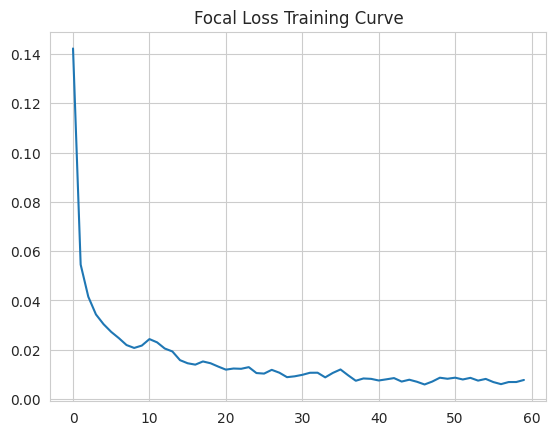

In [6]:
print("--- Training ResNet-MLP with Focal Loss ---")

# Focal Loss Implementation
# Focuses learning on hard-to-classify examples (Rare Attacks)
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

# ResNet Block for MLP
class ResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim)
        )
    def forward(self, x):
        return F.relu(x + self.block(x))

# Deep ResNet Classifier
class ResNetClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU()
        )
        self.res_blocks = nn.Sequential(
            ResBlock(128),
            ResBlock(128),
            ResBlock(128)
        )
        self.output_layer = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_blocks(x)
        return self.output_layer(x)

# Prepare Tensors using Zero-Copy and CPU-Resident Memory
# MEMORY FIX: Keep data on CPU, load batches to GPU dynamically
X_t = torch.from_numpy(X_train_final)
y_t = torch.from_numpy(y_train_bal.values).long()

train_ds = TensorDataset(X_t, y_t)
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)

# Initialize
num_classes = len(np.unique(y_train_bal))
clf_model = ResNetClassifier(X_train_final.shape[1], num_classes).to(device)
optimizer = optim.AdamW(clf_model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = FocalLoss(gamma=2.0) # Using Focal Loss instead of CrossEntropy

# Training Loop
epochs = 60
print(f"Training for {epochs} epochs...")
loss_history = []

for epoch in range(epochs):
    clf_model.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        # MEMORY FIX: Move to GPU here
        xb, yb = xb.to(device), yb.to(device)
        
        optimizer.zero_grad()
        preds = clf_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    loss_history.append(epoch_loss / len(train_dl))
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss_history[-1]:.4f}")

plt.plot(loss_history)
plt.title("Focal Loss Training Curve")
plt.show()

--- Loading NSL-KDD for Validation ---

>>> ENGINEERED VECTOR SPACE ACCURACY (NSL-KDD): 77.18%

Classification Report:
              precision    recall  f1-score   support

         dos       0.96      0.76      0.85      7636
      normal       0.73      0.96      0.83      9711
       probe       0.68      0.76      0.71      2423
         r2l       0.42      0.15      0.22      2574
         u2r       0.28      0.21      0.25       200

    accuracy                           0.77     22544
   macro avg       0.62      0.57      0.57     22544
weighted avg       0.76      0.77      0.75     22544



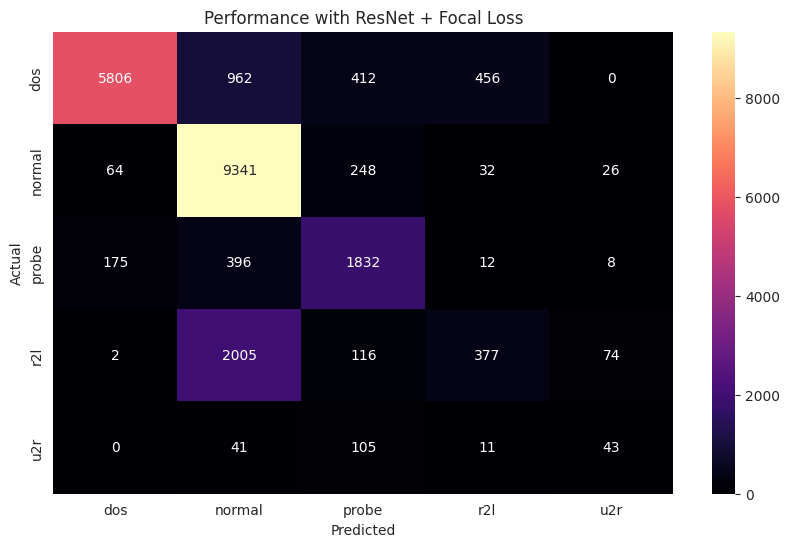

In [7]:
def predict_torch(model, X_np, encoder):
    model.eval()
    # MEMORY FIX: Zero-copy + batch inference
    loader = DataLoader(TensorDataset(torch.from_numpy(X_np)), batch_size=1024, shuffle=False)
    all_probs = []
    
    with torch.no_grad():
        for batch in loader:
            xb = batch[0].to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            
    probs = np.concatenate(all_probs)
    pred_indices = np.argmax(probs, axis=1)
    return encoder.inverse_transform(pred_indices)

# Note: We reuse 'le_y' which was saved earlier, instead of fitting a new one

# --- NSL-KDD Validation ---
print("--- Loading NSL-KDD for Validation ---")
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
NSL_COLS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

try:
    # Load
    df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    df_nsl.drop('difficulty_level', axis=1, inplace=True)
    df_nsl['label'] = df_nsl['label'].astype(str).str.replace('.', '', regex=False)
    df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')
    
    X_nsl = df_nsl.drop(['label', 'category'], axis=1)
    y_nsl = df_nsl['category']
    
    # 1. Vectorize (Same Encoders)
    X_nsl_vec, _ = prepare_vector_input(X_nsl, fit=False, encoders=encoders)
    
    # 2. Transform Pipeline
    # A. Scale (Robust)
    X_nsl_sc = scaler.transform(X_nsl_vec).astype(np.float32)
    # B. NCA Project
    X_nsl_nca = nca.transform(X_nsl_sc).astype(np.float32)
    # C. Isolation Embeddings
    iso_feats_nsl_final = []
    for cls in unique_classes:
         if cls in iso_models:
             iso = iso_models[cls]
             iso_feats_nsl_final.append(iso.decision_function(X_nsl_sc).reshape(-1, 1).astype(np.float32))
    X_nsl_iso = np.hstack(iso_feats_nsl_final)
    
    # D. Autoencoder Score
    X_nsl_ae = get_recon_error_torch(ae_model, X_nsl_sc)

    # E. Stack
    X_nsl_final = np.hstack([X_nsl_sc, X_nsl_nca, X_nsl_iso, X_nsl_ae])
    
    # 3. Predict (Standard inference, Focal Loss handled weight balancing)
    y_nsl_pred = predict_torch(clf_model, X_nsl_final, le_y)
    
    # Evaluate
    acc = accuracy_score(y_nsl, y_nsl_pred)
    print(f"\n>>> ENGINEERED VECTOR SPACE ACCURACY (NSL-KDD): {acc:.2%}")
    print("\nClassification Report:")
    print(classification_report(y_nsl, y_nsl_pred))
    
    labels = sorted(y_nsl.unique())
    cm = confusion_matrix(y_nsl, y_nsl_pred, labels=labels)
    plt.figure(figsize=(10, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=labels, yticklabels=labels)
    plt.title("Performance with ResNet + Focal Loss")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

except Exception as e:
    print(f"Error: {e}")